# Random Forest Real Estate Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import sys
sys.path.append('.')
from data_preprocessing import preprocess_real_estate_data
from feature_creation import create_advanced_features

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')


## Load and Preprocess Data


In [2]:
train_fp = Path('../final_training.csv')
test_fp = Path('../oct_testing.csv')

print("Loading data...")
df_train_raw = pd.read_csv(train_fp, sep='\t' if '\t' in open(train_fp).read(1024) else ',', engine='python')
df_test_raw = pd.read_csv(test_fp, sep='\t' if '\t' in open(test_fp).read(1024) else ',', engine='python')

print(f'Raw train shape: {df_train_raw.shape}')
print(f'Raw test shape: {df_test_raw.shape}')

print("\nPreprocessing data...")
df_train_processed = preprocess_real_estate_data(df_train_raw)
df_test_processed = preprocess_real_estate_data(df_test_raw)

print(f'Processed train shape: {df_train_processed.shape}')
print(f'Processed test shape: {df_test_processed.shape}')

df_train_processed.head()


Loading data...
Raw train shape: (88920, 23)
Raw test shape: (4864, 23)

Preprocessing data...
Processed train shape: (88920, 23)
Processed test shape: (4864, 23)


,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,...,BedroomsTotal,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,FireplaceYN,Stories,NewConstructionYN,GarageSpaces,PostalCode,PropertyAgeAtClose
0,False,False,2025-02-11,875000.0,32.765380,-117.043486,2340.0,San Diego,True,6.0,...,4.0,2025-02-11,2021-01-25,2021-01-05,False,1.0,False,2.0,91942,4.0
1,False,False,2025-02-14,875000.0,32.765038,-117.043568,2165.0,San Diego,True,4.0,...,5.0,2025-02-14,2021-01-14,2021-01-05,False,1.0,False,2.0,91942,4.0
2,False,False,2025-02-18,849000.0,32.765031,-117.043252,2158.0,San Diego,True,4.0,...,4.0,2025-02-18,2021-01-25,2020-10-22,False,1.0,False,2.0,91942,4.0
3,True,False,2025-02-28,1100000.0,33.724000,-118.294924,2545.0,Los Angeles,False,3.0,...,4.0,2025-02-28,2025-01-10,2024-11-18,True,2.0,False,2.0,90731,63.0
4,False,False,2025-02-28,760000.0,37.687556,-122.150114,1692.0,Alameda,True,2.0,...,4.0,2025-02-28,2025-02-28,2025-02-28,True,1.0,False,2.0,94579,75.0


## Advanced Feature Engineering


In [3]:
train_with_features, test_with_features = create_advanced_features(
    df_train_processed.copy(), 
    df_test_processed.copy()
)

print(f'\nFinal train shape: {train_with_features.shape}')
print(f'Final test shape: {test_with_features.shape}')
print(f'\nTotal features created: {len(train_with_features.columns)}')
print(f'\nSample features: {list(train_with_features.columns)[:15]}...')


Creating advanced features...
  - Temporal features
  - Transformations
  - Ratio features
  - Geographical features
  - Clustering
  - Encoding
  - Interaction features
  - Local market features
  - Cleanup
✓ Feature creation complete
  Train: (88920, 89)
  Test:  (4864, 89)

Final train shape: (88920, 89)
Final test shape: (4864, 89)

Total features created: 89

Sample features: ['ViewYN', 'PoolPrivateYN', 'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Stories', 'NewConstructionYN', 'GarageSpaces']...


## Prepare Data for Random Forest


In [4]:
target = 'ClosePrice'
y_train = train_with_features[target].copy()
X_train = train_with_features.drop(columns=[target]).copy()
X_test = test_with_features.drop(columns=[target] if target in test_with_features.columns else []).copy()

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on training data
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    def safe_transform(x):
        try:
            return le.transform([str(x)])[0]
        except (ValueError, KeyError):
            return 0
    
    X_test[col] = X_test[col].astype(str).apply(safe_transform)
    label_encoders[col] = le

bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
for col in bool_cols:
    X_train[col] = X_train[col].astype(int)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(int)

X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

common_cols = X_train.columns.intersection(X_test.columns)
X_train = X_train[common_cols]
X_test = X_test[common_cols]

print(f'\nFinal feature count: {len(X_train.columns)}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

if X_train.isna().sum().sum() > 0:
    print(f"Filling {X_train.isna().sum().sum()} NaN values in train with median")
    X_train = X_train.fillna(X_train.median())
if X_test.isna().sum().sum() > 0:
    print(f"Filling {X_test.isna().sum().sum()} NaN values in test with train median")
    X_test = X_test.fillna(X_train.median())

print(f'\nFinal check - NaN in train: {X_train.isna().sum().sum()}')
print(f'Final check - NaN in test: {X_test.isna().sum().sum()}')

# ============================================================
# REDUCE TARGET-ENCODED FEATURES TO PREVENT OVERFITTING
# ============================================================
print("\n" + "="*60)
print("Reducing target-encoded features to prevent overfitting...")
print("="*60)

# Identify target-encoded features
target_encoded_cols = [col for col in X_train.columns if any(
    x in col for x in ['MeanPrice', 'ZipMean', 'ZipMedian', 'ZipStd', 
                      'ZipMin', 'ZipMax', 'PriceToZip']
)]

print(f"Found {len(target_encoded_cols)} target-encoded features")

# Remove redundant target-encoded features that cause overfitting
features_to_remove = []

# Remove redundant zip code statistics (keep only ZipMeanPrice)
zip_stats = [col for col in target_encoded_cols if 'Zip' in col and col != 'ZipMeanPrice']
features_to_remove.extend(zip_stats)

# Remove PriceToZipMean (too direct relationship with target)
if 'PriceToZipMean' in X_train.columns:
    features_to_remove.append('PriceToZipMean')

# Keep only City_MeanPrice, remove other location MeanPrice features
mean_price_cols = [col for col in target_encoded_cols if 'MeanPrice' in col and 'Zip' not in col and 'RegionCluster' not in col]
if len(mean_price_cols) > 1:
    to_keep = 'City_MeanPrice' if 'City_MeanPrice' in mean_price_cols else mean_price_cols[0]
    features_to_remove.extend([col for col in mean_price_cols if col != to_keep])

# Keep only one cluster mean price (the one with most clusters)
cluster_mean_cols = [col for col in target_encoded_cols if 'RegionCluster' in col and 'MeanPrice' in col]
if len(cluster_mean_cols) > 1:
    # Keep the one with highest cluster number (more general)
    cluster_nums = [int(col.split('_')[1]) for col in cluster_mean_cols]
    to_keep_idx = cluster_nums.index(max(cluster_nums))
    to_keep = cluster_mean_cols[to_keep_idx]
    features_to_remove.extend([col for col in cluster_mean_cols if col != to_keep])

# Remove the features
features_to_remove = [f for f in features_to_remove if f in X_train.columns]

if features_to_remove:
    print(f"\nRemoving {len(features_to_remove)} redundant target-encoded features:")
    for f in features_to_remove[:10]:
        print(f"  - {f}")
    if len(features_to_remove) > 10:
        print(f"  ... and {len(features_to_remove) - 10} more")
    
    X_train = X_train.drop(columns=features_to_remove)
    X_test = X_test.drop(columns=[f for f in features_to_remove if f in X_test.columns])
    
    print(f"\n✓ Reduced features from {len(X_train.columns) + len(features_to_remove)} to {len(X_train.columns)}")
else:
    print("\nNo redundant features to remove")

print("="*60)


Categorical columns to encode: []

Final feature count: 88
Train shape: (88920, 88)
Test shape: (4864, 88)
Filling 619 NaN values in train with median
Filling 131 NaN values in test with train median

Final check - NaN in train: 0
Final check - NaN in test: 0

Reducing target-encoded features to prevent overfitting...
Found 12 target-encoded features

Removing 10 redundant target-encoded features:
  - ZipMedianPrice
  - ZipStdPrice
  - ZipMinPrice
  - ZipMaxPrice
  - PriceToZipMean
  - PriceToZipMean
  - PostalCode_MeanPrice
  - CountyOrParish_MeanPrice
  - RegionCluster_10_MeanPrice
  - RegionCluster_20_MeanPrice

✓ Reduced features from 89 to 79


## Random Forest Model Training with Cross-Validation


In [5]:
print("Training Random Forest model with cross-validation...")
print("Using STRONG regularization to prevent overfitting...")

# STRONG regularization to combat overfitting from remaining target-encoded features
rf_model = RandomForestRegressor(
    n_estimators=150,          # Reduced from 300
    max_depth=12,              # Reduced from 20 (much shallower)
    min_samples_split=30,      # Increased from 5 (much stronger)
    min_samples_leaf=15,       # Increased from 2 (much stronger)
    max_features='sqrt', 
    bootstrap=True,         
    oob_score=True,     
    n_jobs=-1,      
    random_state=42,
    verbose=0
)

print("\nPerforming 5-fold cross-validation...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf_model.fit(X_tr, y_tr)
    
    y_pred = rf_model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    
    mape = np.mean(np.abs((y_val - y_pred) / (y_val + 1))) * 100
    
    cv_results.append({
        'fold': fold + 1,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    })
    
    print(f"Fold {fold+1}: R²={r2:.4f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")

cv_df = pd.DataFrame(cv_results)
print(f"\nCross-Validation Results:")
print(cv_df)
print(f"\nMean CV R²: {cv_df['R²'].mean():.4f} ± {cv_df['R²'].std():.4f}")
print(f"Mean CV RMSE: {cv_df['RMSE'].mean():.2f} ± {cv_df['RMSE'].std():.2f}")
print(f"Mean CV MAPE: {cv_df['MAPE'].mean():.2f}% ± {cv_df['MAPE'].std():.2f}%")

print("\nTraining on full dataset...")
rf_model.fit(X_train, y_train)
print(f"Out-of-bag R² score: {rf_model.oob_score_:.4f}")
print("Training complete!")


Training Random Forest model with cross-validation...
Using STRONG regularization to prevent overfitting...

Performing 5-fold cross-validation...
Fold 1: R²=0.8844, RMSE=304192.88, MAPE=13.77%
Fold 2: R²=0.8837, RMSE=304129.99, MAPE=13.65%
Fold 3: R²=0.8840, RMSE=304098.76, MAPE=13.87%
Fold 4: R²=0.8868, RMSE=306527.51, MAPE=13.78%
Fold 5: R²=0.8780, RMSE=314906.67, MAPE=13.83%

Cross-Validation Results:
   fold           MSE           RMSE        R²       MAPE
0     1  9.253331e+10  304192.878001  0.884439  13.768924
1     2  9.249505e+10  304129.988663  0.883720  13.652708
2     3  9.247605e+10  304098.758551  0.884015  13.865835
3     4  9.395911e+10  306527.507935  0.886772  13.778667
4     5  9.916621e+10  314906.665528  0.878043  13.827299

Mean CV R²: 0.8834 ± 0.0032
Mean CV RMSE: 306771.16 ± 4663.98
Mean CV MAPE: 13.78% ± 0.08%

Training on full dataset...
Out-of-bag R² score: 0.8851
Training complete!


In [6]:
print("Making predictions on test set...")
y_pred_test = rf_model.predict(X_test)

if 'ClosePrice' in df_test_processed.columns:
    y_test = df_test_processed['ClosePrice'].values
    
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)
    mape = np.mean(np.abs((y_test - y_pred_test) / (y_test + 1))) * 100
    
    print(f"\n{'='*60}")
    print(f"TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"R² Score:  {r2:.4f}")
    print(f"MSE:       {mse:,.2f}")
    print(f"RMSE:      {rmse:,.2f}")
    print(f"MAPE:      {mape:.2f}%")
    print(f"{'='*60}")
    
    print(f"\nComparison to Original Random Forest Model:")
    print(f"Original R²:  0.745")
    print(f"Improved R²: {r2:.4f}")
    print(f"Improvement:  {((r2 - 0.745) / 0.745 * 100):.2f}%")
    
    print(f"\nOriginal RMSE: 463,173.73")
    print(f"Improved RMSE: {rmse:,.2f}")
    print(f"Improvement:   {((463173.73 - rmse) / 463173.73 * 100):.2f}%")
    
else:
    print("ClosePrice not available in test set.")
    print(f"Prediction statistics:")
    print(f"  Mean: ${y_pred_test.mean():,.2f}")
    print(f"  Median: ${np.median(y_pred_test):,.2f}")
    print(f"  Std: ${y_pred_test.std():,.2f}")
    print(f"  Min: ${y_pred_test.min():,.2f}")
    print(f"  Max: ${y_pred_test.max():,.2f}")


Making predictions on test set...

TEST SET RESULTS
R² Score:  0.8800
MSE:       94,280,127,716.43
RMSE:      307,050.69
MAPE:      13.90%

Comparison to Original Random Forest Model:
Original R²:  0.745
Improved R²: 0.8800
Improvement:  18.13%

Original RMSE: 463,173.73
Improved RMSE: 307,050.69
Improvement:   33.71%


## Visualizations


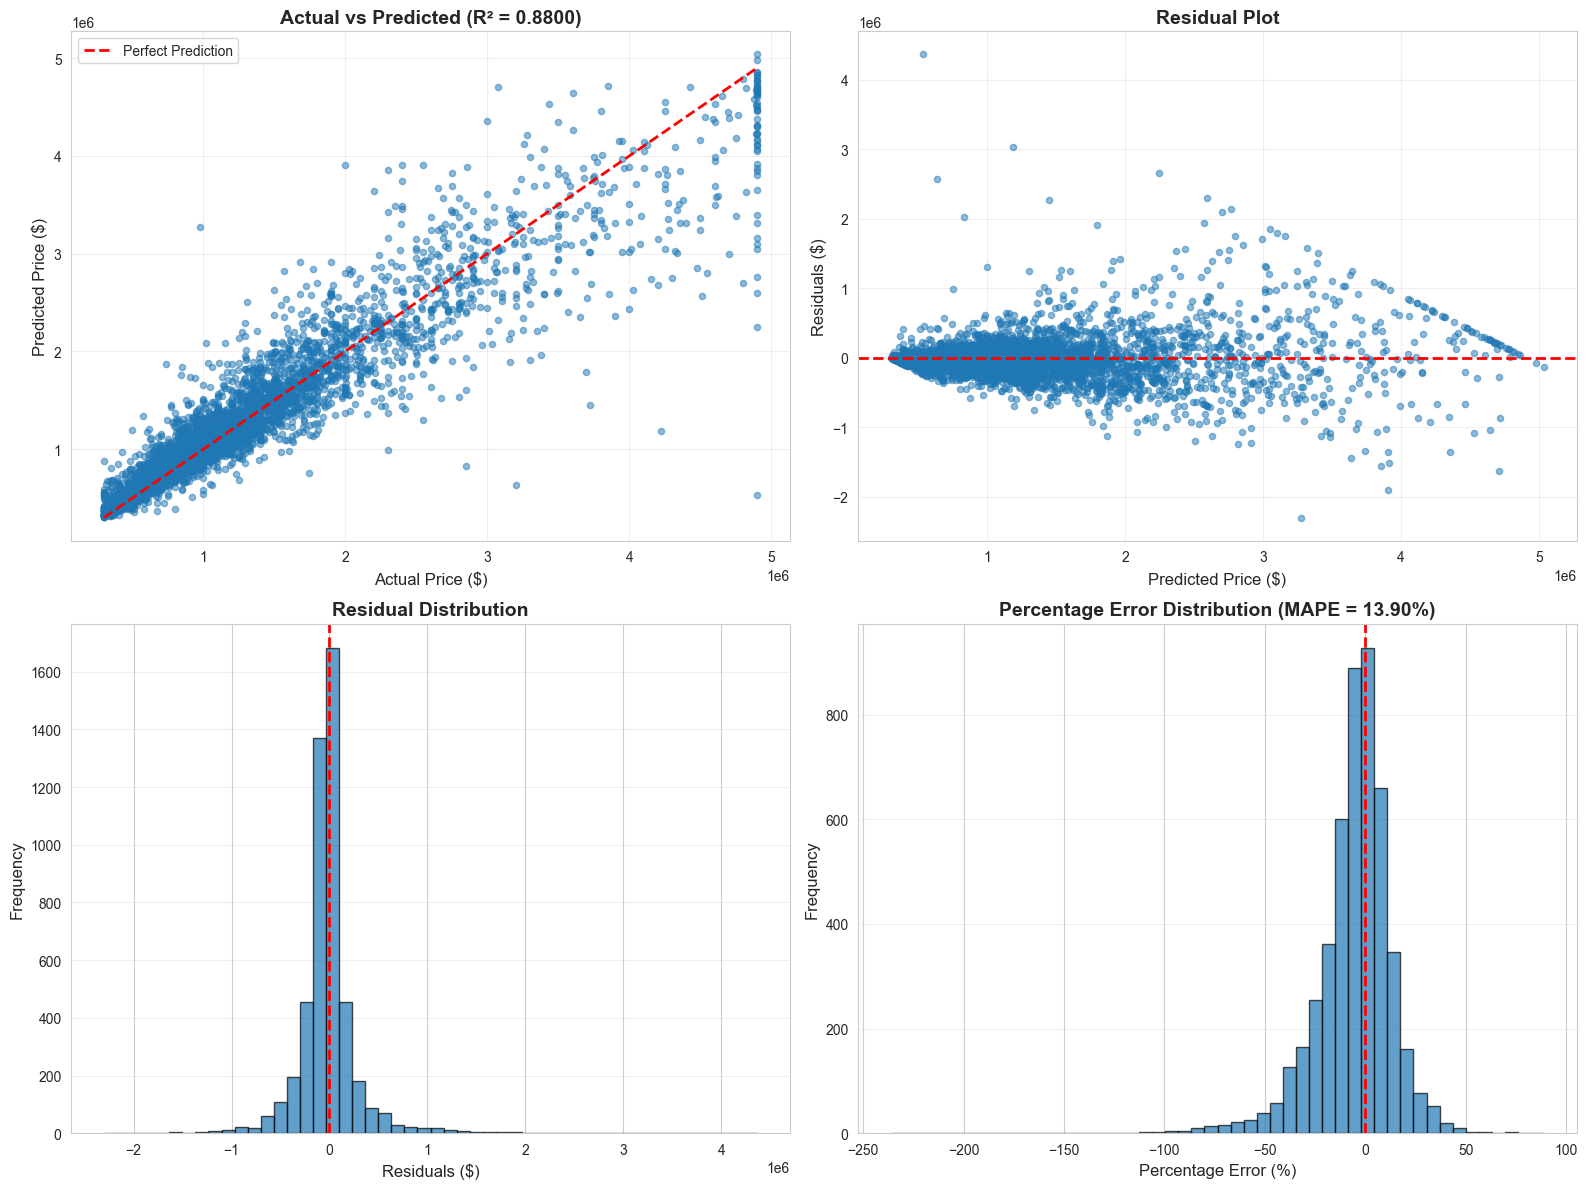


Error Statistics:
  Mean Absolute Error: $175,529.41
  Median Absolute Error: $93,777.80
  Mean Percentage Error: -5.60%
  Median Absolute Percentage Error: 9.29%


In [7]:
if 'ClosePrice' in df_test_processed.columns:
    y_test = df_test_processed['ClosePrice'].values
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Actual vs Predicted scatter
    axes[0, 0].scatter(y_test, y_pred_test, alpha=0.5, s=20)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                    'r--', lw=2, label='Perfect Prediction')
    axes[0, 0].set_xlabel('Actual Price ($)', fontsize=12)
    axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=12)
    axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Residual plot
    residuals = y_test - y_pred_test
    axes[0, 1].scatter(y_pred_test, residuals, alpha=0.5, s=20)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=12)
    axes[0, 1].set_ylabel('Residuals ($)', fontsize=12)
    axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Residual distribution
    axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Residuals ($)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Residual Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Percentage error distribution
    pct_error = (residuals / y_test) * 100
    axes[1, 1].hist(pct_error, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, 1].set_xlabel('Percentage Error (%)', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].set_title(f'Percentage Error Distribution (MAPE = {mape:.2f}%)', 
                        fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"\nError Statistics:")
    print(f"  Mean Absolute Error: ${np.mean(np.abs(residuals)):,.2f}")
    print(f"  Median Absolute Error: ${np.median(np.abs(residuals)):,.2f}")
    print(f"  Mean Percentage Error: {np.mean(pct_error):.2f}%")
    print(f"  Median Absolute Percentage Error: {np.median(np.abs(pct_error)):.2f}%")


## Feature Importance Analysis


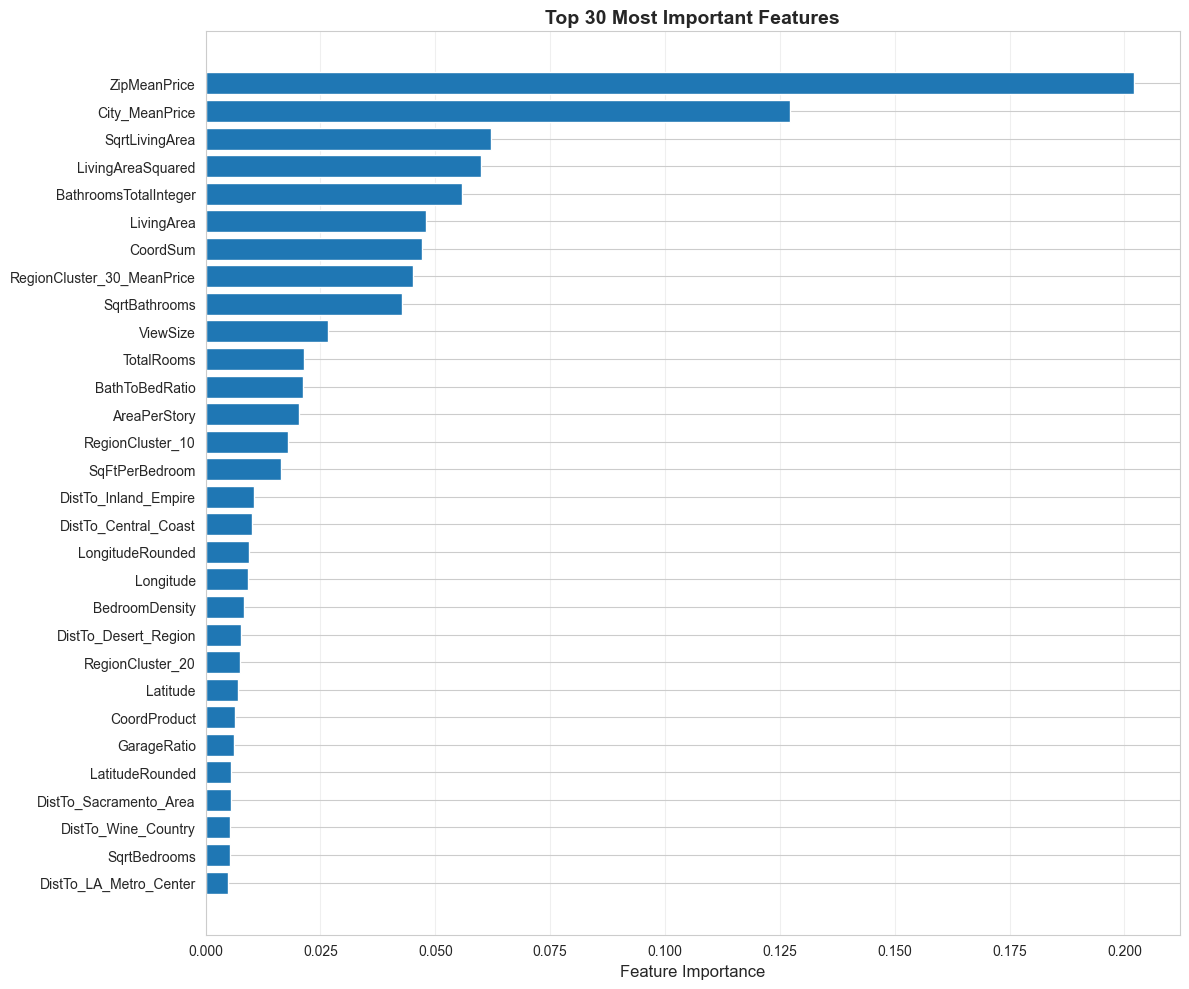


Top 30 Most Important Features:
                   feature  importance
              ZipMeanPrice    0.202011
            City_MeanPrice    0.127166
            SqrtLivingArea    0.062020
         LivingAreaSquared    0.059988
     BathroomsTotalInteger    0.055793
                LivingArea    0.048077
                  CoordSum    0.047080
RegionCluster_30_MeanPrice    0.045221
             SqrtBathrooms    0.042827
                  ViewSize    0.026740
                TotalRooms    0.021363
            BathToBedRatio    0.021198
              AreaPerStory    0.020435
          RegionCluster_10    0.017919
            SqFtPerBedroom    0.016455
      DistTo_Inland_Empire    0.010434
      DistTo_Central_Coast    0.010087
          LongitudeRounded    0.009495
                 Longitude    0.009174
            BedroomDensity    0.008332
      DistTo_Desert_Region    0.007767
          RegionCluster_20    0.007469
                  Latitude    0.007140
              CoordProduct    0

In [8]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 30
fig, ax = plt.subplots(figsize=(12, 10))

top_features = feature_importance.head(top_n)
ax.barh(range(top_n), top_features['importance'].values[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values[::-1], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nTop {top_n} Most Important Features:")
print(feature_importance.head(top_n).to_string(index=False))


## Save Predictions and Model


In [9]:
output_df = df_test_raw.copy()
output_df['PredictedClosePrice'] = y_pred_test

output_path = Path('../oct_testing_rf_improved_predictions.csv')
output_df.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")

import pickle

model_dir = Path('saved_models')
model_dir.mkdir(exist_ok=True)

with open(model_dir / 'random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(model_dir / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print(f"Model saved to {model_dir}/")

feature_importance.to_csv(model_dir / 'feature_importance.csv', index=False)
print("Feature importance saved!")

metrics_summary = {
    'CV_R2_mean': cv_df['R²'].mean(),
    'CV_R2_std': cv_df['R²'].std(),
    'CV_RMSE_mean': cv_df['RMSE'].mean(),
    'CV_RMSE_std': cv_df['RMSE'].std(),
    'CV_MAPE_mean': cv_df['MAPE'].mean(),
    'CV_MAPE_std': cv_df['MAPE'].std(),
}

if 'ClosePrice' in df_test_processed.columns:
    metrics_summary.update({
        'Test_R2': r2,
        'Test_MSE': mse,
        'Test_RMSE': rmse,
        'Test_MAPE': mape
    })

pd.DataFrame([metrics_summary]).to_csv(model_dir / 'model_metrics.csv', index=False)
print("Model metrics saved!")


Predictions saved to ../oct_testing_rf_improved_predictions.csv
Model saved to saved_models/
Feature importance saved!
Model metrics saved!
